# SPY Fragility Dashboard

Research dashboard for SPY downside fragility after abnormal market behavior.

The notebook is organized as a top-down workflow:

1. Configure symbols, dates, thresholds, and forward risk horizons.
2. Load local market history.
3. Build breadth, tactical event-pressure, macro-style, and combined fragility regimes.
4. Review regime performance across next-day and multi-day forward downside outcomes.

This is a research dashboard, not a trading rule. Thresholds are intentionally explicit so they can be tuned after reviewing examples and out-of-sample behavior.


## 1. Setup and Configuration

Edit this section first when changing the sample window, symbol set, or signal thresholds.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

START_DATE = '2021-01-01'
END_DATE = None  # None uses latest common available date.

SECTOR_SYMBOLS = ['XLF', 'XLK', 'XLY', 'XLP', 'XLU', 'XLV', 'XLE', 'XLI', 'XLB', 'XLRE']
BASE_SYMBOLS = ['SPY', 'RSP', 'QQQ', 'IWM', 'HYG', 'LQD', 'TLT', 'SHY', 'UUP', '^VIX', '^VIX9D', '^VIX3M']
SYMBOLS = BASE_SYMBOLS + SECTOR_SYMBOLS

FORWARD_TAIL_THRESHOLDS = {
    1: -0.015,  # next trading day close-to-close drop
    3: -0.020,  # worst close-to-close path over the next three trading days
    5: -0.030,  # worst close-to-close path over the next week
    10: -0.040,  # worst close-to-close path over the next two weeks
}
PRIMARY_TAIL_HORIZON = 5
MAX_FORWARD_HORIZON = max(FORWARD_TAIL_THRESHOLDS)
TAIL_THRESHOLD = FORWARD_TAIL_THRESHOLDS[1]

BREADTH_Z_THRESHOLD = 1.0
SECTOR_DOWN_PCT_THRESHOLD = 0.70
CREDIT_STRESS_Z_THRESHOLD = 1.0
VOL_SHOCK_Z_THRESHOLD = 1.5
LATE_LIQUIDATION_THRESHOLD = -0.008
MACRO_FLAG_Z_THRESHOLD = 1.0
MACRO_WATCH_SCORE = 2
MACRO_RISK_OFF_SCORE = 3
FRAGILITY_EVENT_CONFIRMATION_SCORE = 1
ROLL_LONG = 252
ROLL_MED = 126
ROLL_SHORT = 63


## 2. Data Loading Helpers

These helpers find the project data directory, load the latest parquet file for each symbol, and keep rolling z-scores point-in-time by shifting the reference window.


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        has_project_markers = (candidate / 'pyproject.toml').exists() and (candidate / 'activeportfolio').exists()
        has_market_data = (candidate / 'data' / 'market').exists()
        if has_project_markers and has_market_data:
            return candidate
    raise RuntimeError('Could not locate project root containing pyproject.toml, activeportfolio, and data/market')


REPO_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = REPO_ROOT / 'data' / 'market'


def latest_history_file(symbol: str) -> Path:
    symbol_dir = DATA_ROOT / symbol
    files = sorted(symbol_dir.glob('history_*.parquet'))
    if not files:
        raise FileNotFoundError(f'No parquet history files found for {symbol} under {symbol_dir}')
    return files[-1]


def load_symbol(symbol: str) -> pd.DataFrame:
    df = pd.read_parquet(latest_history_file(symbol)).copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').drop_duplicates('Date').set_index('Date')
    return df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].rename(
        columns={
            'Open': f'{symbol}_open',
            'High': f'{symbol}_high',
            'Low': f'{symbol}_low',
            'Close': f'{symbol}_close',
            'Adj Close': f'{symbol}_adj_close',
            'Volume': f'{symbol}_volume',
        }
    )


def rolling_z(series: pd.Series, window: int) -> pd.Series:
    prior_mean = series.rolling(window, min_periods=max(20, window // 4)).mean().shift(1)
    prior_std = series.rolling(window, min_periods=max(20, window // 4)).std().shift(1)
    return (series - prior_mean) / prior_std.replace(0, np.nan)


## 3. Load Market History

The dashboard uses the latest local history file for every configured symbol and keeps rows where the core SPY/RSP/VIX fields are available.


In [3]:
raw = pd.concat([load_symbol(symbol) for symbol in SYMBOLS], axis=1).sort_index()

if START_DATE:
    raw = raw.loc[pd.Timestamp(START_DATE):]
if END_DATE:
    raw = raw.loc[:pd.Timestamp(END_DATE)]

required = ['SPY_adj_close', 'RSP_adj_close', '^VIX_adj_close']
frame = raw.dropna(subset=required).copy()

print('Repo root:', REPO_ROOT)
print('Loaded symbols:', len(SYMBOLS))
print('Window:', frame.index.min().date(), '->', frame.index.max().date())
print('Rows:', len(frame))


Repo root: /home/rockebull/proj/TradingAgents
Loaded symbols: 22
Window: 2021-07-19 -> 2026-07-16
Rows: 1254


## 4. Build Daily Returns and Forward Risk Labels

Forward labels include both ending return and worst close-to-close path return. The path measure is the primary fragility metric because a regime can correctly flag stress even if SPY recovers by the end of the horizon.


In [4]:
df = frame.copy()

for symbol in SYMBOLS:
    close_col = f'{symbol}_adj_close'
    if close_col in df:
        df[f'{symbol}_ret'] = df[close_col].pct_change(fill_method=None)

df['spy_ret'] = df['SPY_ret']
spy_price = df['SPY_adj_close']
forward_path_returns = pd.concat(
    {step: spy_price.shift(-step) / spy_price - 1 for step in range(1, MAX_FORWARD_HORIZON + 1)},
    axis=1,
)

for horizon, threshold in FORWARD_TAIL_THRESHOLDS.items():
    horizon_path = forward_path_returns.loc[:, 1:horizon]
    has_full_horizon = forward_path_returns[horizon].notna()
    df[f'fwd_{horizon}d_ret'] = forward_path_returns[horizon]
    df[f'fwd_{horizon}d_min_ret'] = horizon_path.min(axis=1).where(has_full_horizon)
    df[f'fwd_{horizon}d_tail'] = (df[f'fwd_{horizon}d_min_ret'] <= threshold).where(has_full_horizon)

# Backward-compatible aliases for the original next-day metrics.
df['spy_next_ret'] = df['fwd_1d_ret']
df['spy_next_tail'] = df['fwd_1d_tail']


## 5. Breadth Break Signal

Breadth stress is abnormal equal-weight underperformance versus cap-weight SPY, confirmed by broad sector weakness.


In [5]:
df['breadth_gap'] = df['RSP_ret'] - df['SPY_ret']
df['breadth_stress'] = -df['breadth_gap']
df['breadth_z'] = rolling_z(df['breadth_stress'], ROLL_LONG)

sector_ret_cols = [f'{symbol}_ret' for symbol in SECTOR_SYMBOLS if f'{symbol}_ret' in df]
df['sector_count'] = df[sector_ret_cols].notna().sum(axis=1)
df['sector_down_count'] = (df[sector_ret_cols] < 0).sum(axis=1)
df['sector_down_pct'] = df['sector_down_count'] / df['sector_count'].replace(0, np.nan)
df['breadth_break'] = (
    (df['spy_ret'] < 0)
    & (df['breadth_z'] >= BREADTH_Z_THRESHOLD)
    & (df['sector_down_pct'] >= SECTOR_DOWN_PCT_THRESHOLD)
)


## 6. Tactical Event-Pressure Regime

The tactical layer captures same-day pressure events. `risk_off` is reserved for unusually clustered events; one or two events remain `watch` so the label does not overstate noisy single-day stress.


In [6]:
df['credit_stress'] = -(df['HYG_ret'] - df['LQD_ret'])
df['credit_z'] = rolling_z(df['credit_stress'], ROLL_MED)
df['vix_ret'] = df['^VIX_adj_close'].pct_change(fill_method=None)
df['vix_shock_z'] = rolling_z(df['vix_ret'], ROLL_MED)
df['spy_intraday_ret'] = df['SPY_close'] / df['SPY_open'] - 1

df['late_liquidation'] = (df['spy_ret'] < 0) & (df['spy_intraday_ret'] <= LATE_LIQUIDATION_THRESHOLD)
df['credit_stress_flag'] = (df['spy_ret'] < 0) & (df['credit_z'] >= CREDIT_STRESS_Z_THRESHOLD)
df['vol_shock_flag'] = (df['spy_ret'] < 0) & (df['vix_shock_z'] >= VOL_SHOCK_Z_THRESHOLD)

rule_flags = ['breadth_break', 'credit_stress_flag', 'vol_shock_flag', 'late_liquidation']
df['rule_stress_score'] = df[rule_flags].sum(axis=1)
df['rule_regime'] = np.select(
    [df['rule_stress_score'] >= 3, df['rule_stress_score'] >= 1],
    ['risk_off', 'watch'],
    default='normal',
)


## 7. Macro-Style Regime

The macro-style regime uses market-implied proxies for volatility pressure, credit weakness, Treasury duration weakness, and dollar strength.


In [7]:
df['vix_level_z'] = rolling_z(df['^VIX_adj_close'], ROLL_LONG)
df['vix_backwardation'] = df['^VIX9D_adj_close'] > df['^VIX3M_adj_close']
df['credit_ratio'] = df['HYG_adj_close'] / df['LQD_adj_close']
df['credit_ratio_stress_z'] = rolling_z(-df['credit_ratio'].pct_change(20, fill_method=None), ROLL_LONG)
df['duration_stress_z'] = rolling_z(-(df['TLT_ret'] - df['SHY_ret']), ROLL_MED)
df['dollar_strength_z'] = rolling_z(df['UUP_adj_close'].pct_change(20, fill_method=None), ROLL_LONG)

macro_flag_cols = [
    'macro_elevated_vix',
    'macro_vix_backwardation',
    'macro_weak_credit',
    'macro_duration_pressure',
    'macro_dollar_strength',
]
df['macro_elevated_vix'] = df['vix_level_z'] >= MACRO_FLAG_Z_THRESHOLD
df['macro_vix_backwardation'] = df['vix_backwardation']
df['macro_weak_credit'] = df['credit_ratio_stress_z'] >= MACRO_FLAG_Z_THRESHOLD
df['macro_duration_pressure'] = df['duration_stress_z'] >= MACRO_FLAG_Z_THRESHOLD
df['macro_dollar_strength'] = df['dollar_strength_z'] >= MACRO_FLAG_Z_THRESHOLD

df['macro_stress_score'] = df[macro_flag_cols].sum(axis=1)
df['macro_regime'] = np.select(
    [df['macro_stress_score'] >= MACRO_RISK_OFF_SCORE, df['macro_stress_score'] == MACRO_WATCH_SCORE],
    ['risk_off', 'watch'],
    default='normal',
)


## 8. Combined Fragility Regime

The combined regime treats macro stress watch-or-worse as the primary day-to-day risk-off signal and tactical event clusters as acute confirmation. The prior confirmation-heavy rule is retained as `fragility_regime_v1` for comparison.


In [8]:
df['fragility_risk_off_v1'] = (
    (df['macro_stress_score'] >= MACRO_RISK_OFF_SCORE)
    | (
        (df['macro_stress_score'] >= MACRO_WATCH_SCORE)
        & (df['rule_stress_score'] >= FRAGILITY_EVENT_CONFIRMATION_SCORE)
    )
)
df['fragility_watch_v1'] = (
    ~df['fragility_risk_off_v1']
    & (
        (df['macro_stress_score'] >= MACRO_WATCH_SCORE)
        | (df['rule_stress_score'] >= FRAGILITY_EVENT_CONFIRMATION_SCORE)
        | df['breadth_break']
    )
)
df['fragility_regime_v1'] = np.select(
    [df['fragility_risk_off_v1'], df['fragility_watch_v1']],
    ['risk_off', 'watch'],
    default='normal',
)

df['fragility_risk_off'] = (df['macro_stress_score'] >= MACRO_WATCH_SCORE) | (df['rule_stress_score'] >= 3)
df['fragility_watch'] = (
    ~df['fragility_risk_off']
    & ((df['macro_stress_score'] == 1) | df['rule_stress_score'].between(1, 2))
)
df['fragility_regime'] = np.select(
    [df['fragility_risk_off'], df['fragility_watch']],
    ['risk_off', 'watch'],
    default='normal',
)


## 9. Dashboard Signal Table

`signals` keeps the daily dashboard fields, including latest rows whose forward outcomes are not complete yet. `evaluation_signals` requires the maximum configured forward horizon so regime comparisons use a common sample.


In [9]:
forward_cols = []
for horizon in FORWARD_TAIL_THRESHOLDS:
    forward_cols.extend([f'fwd_{horizon}d_ret', f'fwd_{horizon}d_min_ret', f'fwd_{horizon}d_tail'])

dashboard_cols = [
    'spy_ret', 'spy_next_ret', 'breadth_gap', 'breadth_z', 'sector_down_count', 'sector_count',
    'sector_down_pct', 'breadth_break', 'credit_z', 'vix_shock_z', 'credit_stress_flag',
    'vol_shock_flag', 'late_liquidation', 'rule_stress_score', 'rule_regime',
    'macro_stress_score', 'macro_regime', 'fragility_regime_v1', 'fragility_regime', 'spy_next_tail',
    *forward_cols,
    *macro_flag_cols,
]

dashboard_signals = df[dashboard_cols].dropna(subset=['spy_ret']).copy()
evaluation_signals = dashboard_signals.dropna(subset=[f'fwd_{MAX_FORWARD_HORIZON}d_min_ret']).copy()
signals = dashboard_signals

display(signals.tail())


,spy_ret,spy_next_ret,breadth_gap,breadth_z,sector_down_count,sector_count,sector_down_pct,breadth_break,credit_z,vix_shock_z,credit_stress_flag,vol_shock_flag,late_liquidation,rule_stress_score,rule_regime,macro_stress_score,macro_regime,fragility_regime_v1,fragility_regime,spy_next_tail,fwd_1d_ret,fwd_1d_min_ret,fwd_1d_tail,fwd_3d_ret,fwd_3d_min_ret,fwd_3d_tail,fwd_5d_ret,fwd_5d_min_ret,fwd_5d_tail,fwd_10d_ret,fwd_10d_min_ret,fwd_10d_tail,macro_elevated_vix,macro_vix_backwardation,macro_weak_credit,macro_duration_pressure,macro_dollar_strength
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-07-10,0.004310,-0.007656,-0.000563,0.080228,1,10,0.1,False,-0.782012,-0.652302,False,False,False,0,normal,0,normal,normal,normal,False,-0.007656,-0.007656,False,-0.000185,-0.007656,False,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
2026-07-13,-0.007656,0.003551,0.007329,-1.480898,4,10,0.4,False,-0.980007,1.639358,False,True,False,1,watch,1,normal,watch,watch,False,0.003551,0.003551,False,0.002069,0.002069,False,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,True
2026-07-14,0.003551,0.003964,-0.007192,1.393372,5,10,0.5,False,0.224183,-0.500527,False,False,False,0,normal,0,normal,normal,normal,False,0.003964,0.003964,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
2026-07-15,0.003964,-0.005419,-0.006212,1.194130,5,10,0.5,False,0.941085,-0.642306,False,False,False,0,normal,0,normal,normal,normal,False,-0.005419,-0.005419,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
2026-07-16,-0.005419,NaN,0.015232,-3.021566,1,10,0.1,False,-0.222609,0.749008,False,False,False,0,normal,0,normal,normal,normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False


## 10. Signal Summary

Compare each condition with all days and SPY-down days across multiple forward horizons. Tail rates use the worst close-to-close path return inside each horizon, not just the final return.


In [10]:
def summarize_signal(mask: pd.Series, label: str) -> dict[str, object]:
    sample = evaluation_signals.loc[mask.reindex(evaluation_signals.index).fillna(False)]
    row: dict[str, object] = {'signal': label, 'days': len(sample)}
    for horizon, threshold in FORWARD_TAIL_THRESHOLDS.items():
        tail_col = f'fwd_{horizon}d_tail'
        min_ret_col = f'fwd_{horizon}d_min_ret'
        final_ret_col = f'fwd_{horizon}d_ret'
        row[f'{horizon}d_path_tail_rate'] = sample[tail_col].mean()
        row[f'{horizon}d_avg_min_ret'] = sample[min_ret_col].mean()
        row[f'{horizon}d_median_min_ret'] = sample[min_ret_col].median()
        row[f'{horizon}d_avg_final_ret'] = sample[final_ret_col].mean()
        row[f'{horizon}d_tail_threshold'] = threshold
    return row


primary_tail_col = f'{PRIMARY_TAIL_HORIZON}d_path_tail_rate'
baseline_all = summarize_signal(pd.Series(True, index=evaluation_signals.index), 'all_days')
baseline_spy_down = summarize_signal(evaluation_signals['spy_ret'] < 0, 'spy_down_days')
rows = [
    baseline_all,
    baseline_spy_down,
    summarize_signal(evaluation_signals['breadth_z'] >= BREADTH_Z_THRESHOLD, 'breadth_z_only'),
    summarize_signal(evaluation_signals['breadth_break'], 'breadth_break'),
    summarize_signal(evaluation_signals['rule_regime'] == 'watch', 'event_watch'),
    summarize_signal(evaluation_signals['rule_regime'] == 'risk_off', 'event_risk_off'),
    summarize_signal(evaluation_signals['macro_regime'] == 'watch', 'macro_watch'),
    summarize_signal(evaluation_signals['macro_regime'] == 'risk_off', 'macro_risk_off'),
    summarize_signal(evaluation_signals['fragility_regime_v1'] == 'watch', 'fragility_watch_v1'),
    summarize_signal(evaluation_signals['fragility_regime_v1'] == 'risk_off', 'fragility_risk_off_v1'),
    summarize_signal(evaluation_signals['fragility_regime'] == 'watch', 'fragility_watch'),
    summarize_signal(evaluation_signals['fragility_regime'] == 'risk_off', 'fragility_risk_off'),
    summarize_signal(
        (evaluation_signals['rule_stress_score'] >= FRAGILITY_EVENT_CONFIRMATION_SCORE)
        & (evaluation_signals['macro_stress_score'] >= MACRO_WATCH_SCORE),
        'event_confirmed_by_macro_watch_or_worse',
    ),
]

summary = pd.DataFrame(rows)
summary[f'{PRIMARY_TAIL_HORIZON}d_tail_lift_vs_all'] = summary[primary_tail_col] / baseline_all[primary_tail_col]
summary[f'{PRIMARY_TAIL_HORIZON}d_tail_lift_vs_spy_down'] = summary[primary_tail_col] / baseline_spy_down[primary_tail_col]

summary_display_cols = [
    'signal', 'days',
    *[f'{horizon}d_path_tail_rate' for horizon in FORWARD_TAIL_THRESHOLDS],
    f'{PRIMARY_TAIL_HORIZON}d_tail_lift_vs_all',
    f'{PRIMARY_TAIL_HORIZON}d_tail_lift_vs_spy_down',
    f'{PRIMARY_TAIL_HORIZON}d_avg_min_ret',
    f'{PRIMARY_TAIL_HORIZON}d_avg_final_ret',
]
display(summary[summary_display_cols])

score_bucket_rows = []
for score in sorted(evaluation_signals['rule_stress_score'].dropna().unique()):
    score_bucket_rows.append(summarize_signal(evaluation_signals['rule_stress_score'] == score, f'event_score_{int(score)}'))
for score in sorted(evaluation_signals['macro_stress_score'].dropna().unique()):
    score_bucket_rows.append(summarize_signal(evaluation_signals['macro_stress_score'] == score, f'macro_score_{int(score)}'))

score_buckets = pd.DataFrame(score_bucket_rows)
score_buckets[f'{PRIMARY_TAIL_HORIZON}d_tail_lift_vs_all'] = score_buckets[primary_tail_col] / baseline_all[primary_tail_col]
score_bucket_display_cols = [
    'signal', 'days',
    *[f'{horizon}d_path_tail_rate' for horizon in FORWARD_TAIL_THRESHOLDS],
    f'{PRIMARY_TAIL_HORIZON}d_tail_lift_vs_all',
    f'{PRIMARY_TAIL_HORIZON}d_avg_min_ret',
]
display(score_buckets[score_bucket_display_cols])


,signal,days,1d_path_tail_rate,3d_path_tail_rate,5d_path_tail_rate,10d_path_tail_rate,5d_tail_lift_vs_all,5d_tail_lift_vs_spy_down,5d_avg_min_ret,5d_avg_final_ret
0,all_days,1243,0.067578,0.127916,0.104586,0.131939,1.000000,1.074380,-0.009405,0.002704
1,spy_down_days,565,0.084956,0.134513,0.097345,0.125664,0.930769,1.000000,-0.009154,0.004241
2,breadth_z_only,191,0.062827,0.099476,0.073298,0.099476,0.700846,0.752975,-0.007677,0.005587
3,breadth_break,50,0.100000,0.100000,0.040000,0.100000,0.382462,0.410909,-0.009083,0.007288
4,event_watch,255,0.090196,0.133333,0.094118,0.145098,0.899910,0.966845,-0.008377,0.006048
5,event_risk_off,26,0.076923,0.307692,0.269231,0.307692,2.574260,2.765734,-0.022002,-0.004333
6,macro_watch,156,0.108974,0.198718,0.185897,0.179487,1.777465,1.909674,-0.013186,0.003192
7,macro_risk_off,85,0.129412,0.188235,0.164706,0.164706,1.574842,1.691979,-0.012425,0.010285
8,fragility_watch_v1,271,0.095941,0.184502,0.143911,0.158672,1.376015,1.478363,-0.011329,0.002321
9,fragility_risk_off_v1,145,0.117241,0.172414,0.158621,0.179310,1.516658,1.629467,-0.012046,0.007520


,signal,days,1d_path_tail_rate,3d_path_tail_rate,5d_path_tail_rate,10d_path_tail_rate,5d_tail_lift_vs_all,5d_avg_min_ret
0,event_score_0,962,0.061331,0.121622,0.102911,0.123701,0.983984,-0.009337
1,event_score_1,176,0.107955,0.153409,0.096591,0.147727,0.923558,-0.008555
2,event_score_2,79,0.050633,0.088608,0.088608,0.139241,0.847225,-0.007982
3,event_score_3,22,0.090909,0.363636,0.318182,0.363636,3.042308,-0.025048
4,event_score_4,4,0.000000,0.000000,0.000000,0.000000,0.000000,-0.005249
5,macro_score_0,612,0.042484,0.088235,0.068627,0.116013,0.656184,-0.007934
6,macro_score_1,390,0.076923,0.148718,0.115385,0.130769,1.103254,-0.009543
7,macro_score_2,156,0.108974,0.198718,0.185897,0.179487,1.777465,-0.013186
8,macro_score_3,63,0.158730,0.190476,0.158730,0.158730,1.517705,-0.012479
9,macro_score_4,22,0.045455,0.181818,0.181818,0.181818,1.738462,-0.012271


## 11. Recent Breadth-Break Examples

Use these rows to inspect the most recent breadth breaks and their forward path outcomes.


In [11]:
example_cols = [
    'spy_ret', 'fwd_1d_ret', 'fwd_3d_min_ret', 'fwd_5d_min_ret', 'fwd_10d_min_ret',
    'breadth_gap', 'breadth_z', 'sector_down_count', 'sector_count', 'sector_down_pct',
    'credit_z', 'vix_shock_z', 'rule_regime', 'macro_regime', 'fragility_regime',
    'fwd_5d_tail',
]

recent_examples = evaluation_signals.loc[evaluation_signals['breadth_break']].tail(20).copy()
recent_examples_display = recent_examples.assign(
    spy_ret=lambda x: x['spy_ret'] * 100,
    fwd_1d_ret=lambda x: x['fwd_1d_ret'] * 100,
    fwd_3d_min_ret=lambda x: x['fwd_3d_min_ret'] * 100,
    fwd_5d_min_ret=lambda x: x['fwd_5d_min_ret'] * 100,
    fwd_10d_min_ret=lambda x: x['fwd_10d_min_ret'] * 100,
    breadth_gap=lambda x: x['breadth_gap'] * 100,
    sector_down_pct=lambda x: x['sector_down_pct'] * 100,
)[example_cols].round(2)

display(recent_examples_display)


,spy_ret,fwd_1d_ret,fwd_3d_min_ret,fwd_5d_min_ret,fwd_10d_min_ret,breadth_gap,breadth_z,sector_down_count,sector_count,sector_down_pct,credit_z,vix_shock_z,rule_regime,macro_regime,fragility_regime,fwd_5d_tail
Date,,,,,,,,,,,,,,,,
2023-12-05,-0.02,-0.40,-0.40,-0.40,-0.40,-0.87,2.32,8,10,80.0,2.11,-0.33,watch,normal,watch,False
2023-12-15,-0.16,0.56,-0.23,-0.23,-0.23,-0.55,1.37,7,10,70.0,0.24,-0.30,watch,normal,watch,False
2024-01-03,-0.82,-0.32,-0.32,-0.32,-0.32,-0.66,1.64,8,10,80.0,0.17,1.17,watch,normal,watch,False
2024-02-05,-0.36,0.29,0.29,0.29,0.29,-0.50,1.12,8,10,80.0,-1.40,-0.26,watch,watch,risk_off,False
2024-03-14,-0.20,-0.69,-0.69,-0.69,-0.69,-0.70,1.64,8,10,80.0,-0.76,0.89,watch,normal,watch,False
2024-03-22,-0.19,-0.28,-0.46,-0.46,-1.56,-0.45,1.05,8,10,80.0,1.35,0.21,watch,normal,watch,False
2024-04-10,-1.00,0.75,-1.88,-2.64,-3.69,-0.70,1.67,9,10,90.0,-1.66,1.13,watch,watch,risk_off,False
2024-05-23,-0.73,0.66,0.03,-0.64,-0.64,-0.67,1.56,10,10,100.0,-0.27,0.83,watch,normal,watch,False
2024-05-29,-0.70,-0.66,-0.66,-0.66,-0.66,-0.47,1.07,10,10,100.0,-0.81,2.18,watch,normal,watch,False


## 12. Two-Year Dashboard Chart

The chart shows normalized SPY/RSP, breadth stress, regime stress scores, and SPY daily returns with 5-day path-tail signal markers.


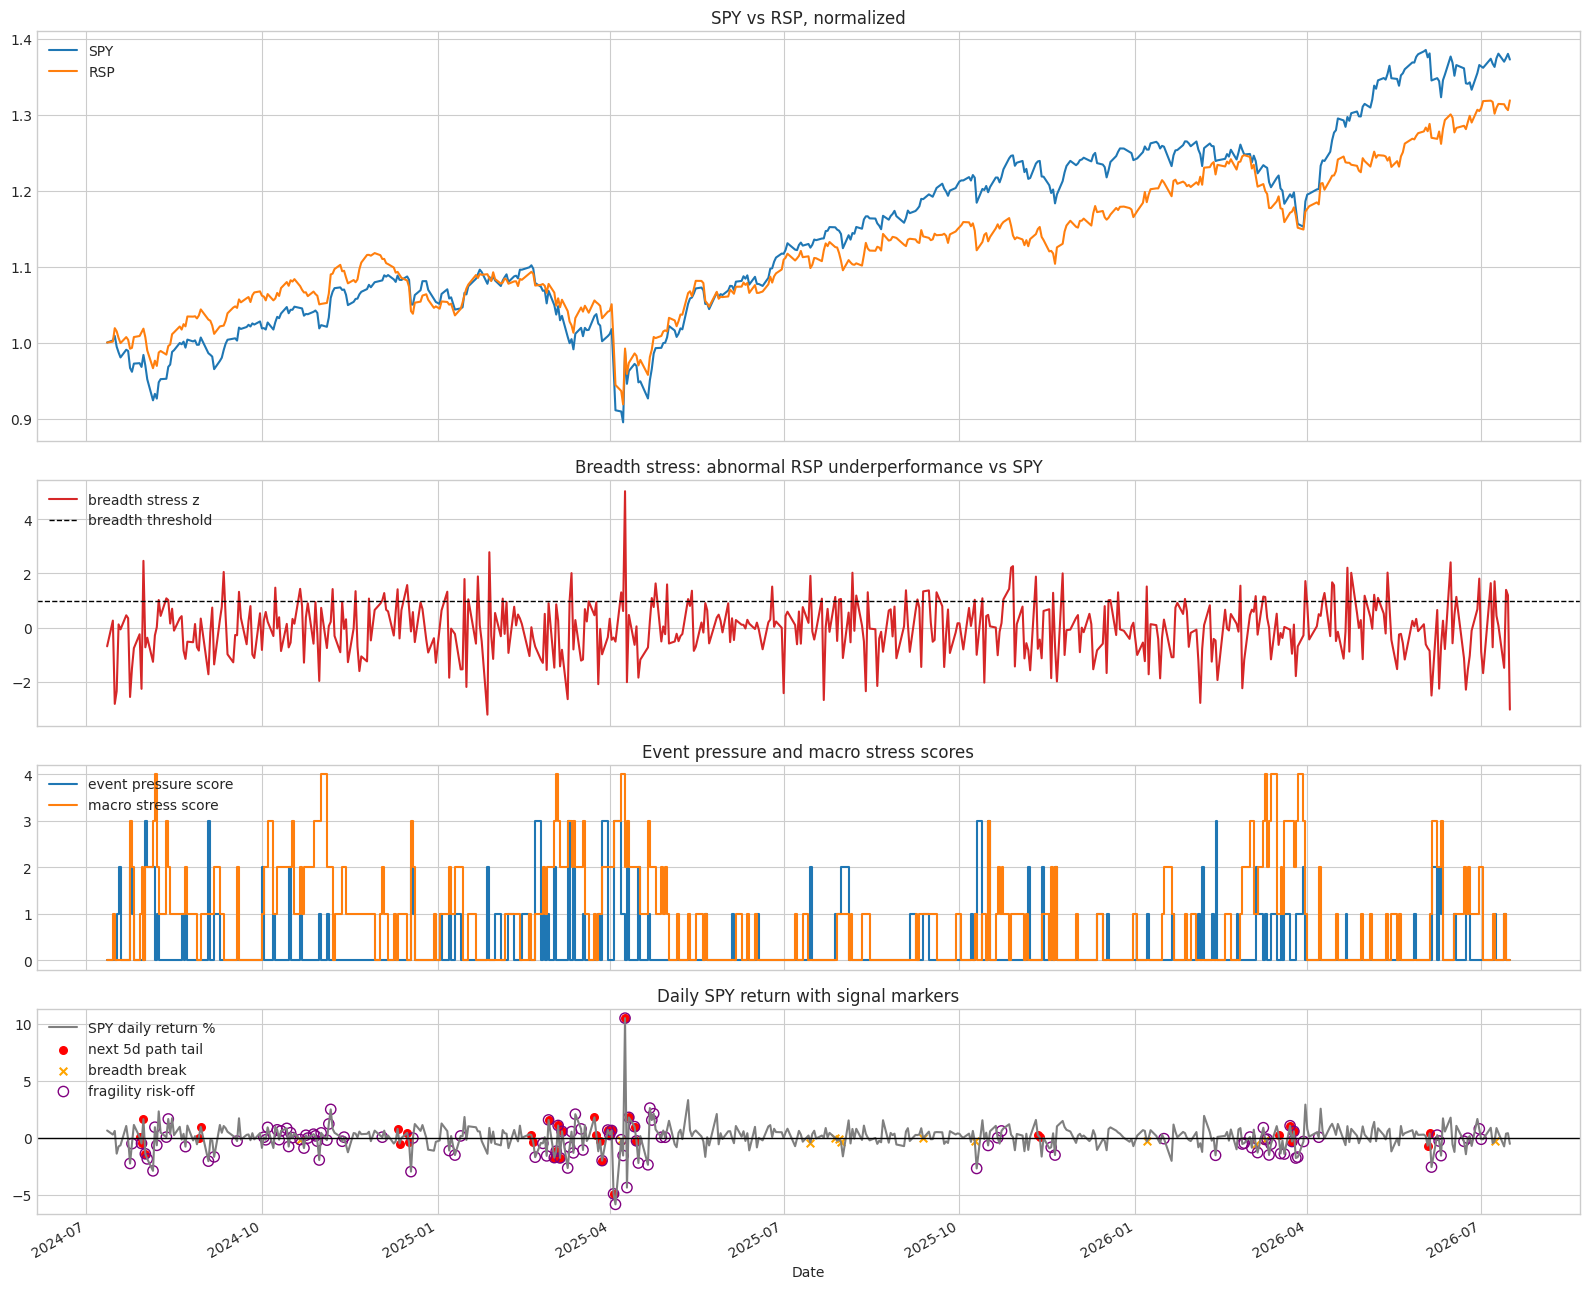

In [12]:
plot_df = signals.tail(504).copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True, height_ratios=[2.0, 1.2, 1.0, 1.0])

ax = axes[0]
(df.loc[plot_df.index, 'SPY_adj_close'] / df.loc[plot_df.index, 'SPY_adj_close'].iloc[0]).plot(ax=ax, label='SPY')
(df.loc[plot_df.index, 'RSP_adj_close'] / df.loc[plot_df.index, 'RSP_adj_close'].iloc[0]).plot(ax=ax, label='RSP')
ax.set_title('SPY vs RSP, normalized')
ax.legend(loc='upper left')

ax = axes[1]
plot_df['breadth_z'].plot(ax=ax, color='tab:red', label='breadth stress z')
ax.axhline(BREADTH_Z_THRESHOLD, color='black', linestyle='--', linewidth=1, label='breadth threshold')
ax.set_title('Breadth stress: abnormal RSP underperformance vs SPY')
ax.legend(loc='upper left')

ax = axes[2]
plot_df['rule_stress_score'].plot(ax=ax, drawstyle='steps-post', label='event pressure score')
plot_df['macro_stress_score'].plot(ax=ax, drawstyle='steps-post', label='macro stress score')
ax.set_title('Event pressure and macro stress scores')
ax.legend(loc='upper left')

ax = axes[3]
plot_df['spy_ret'].mul(100).plot(ax=ax, color='tab:gray', label='SPY daily return %')
tail_days = plot_df.index[plot_df[f'fwd_{PRIMARY_TAIL_HORIZON}d_tail'] == True]
ax.scatter(
    tail_days,
    plot_df.loc[tail_days, 'spy_ret'] * 100,
    color='red',
    s=30,
    label=f'next {PRIMARY_TAIL_HORIZON}d path tail',
)
break_days = plot_df.index[plot_df['breadth_break']]
ax.scatter(break_days, plot_df.loc[break_days, 'spy_ret'] * 100, color='orange', s=30, marker='x', label='breadth break')
fragile_days = plot_df.index[plot_df['fragility_regime'] == 'risk_off']
ax.scatter(fragile_days, plot_df.loc[fragile_days, 'spy_ret'] * 100, facecolors='none', edgecolors='purple', s=55, label='fragility risk-off')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Daily SPY return with signal markers')
ax.legend(loc='upper left')

plt.tight_layout()


## 13. Latest Dashboard Snapshot

The final row is the most recent local market date available after requiring SPY, RSP, and VIX data. Forward outcomes near the end of the sample may be incomplete until enough future bars are available.


In [13]:
latest = signals.iloc[-1]

print('Latest dashboard date:', signals.index[-1].date())
print('Event-pressure regime:', latest['rule_regime'], 'score=', int(latest['rule_stress_score']))
print('Macro regime:', latest['macro_regime'], 'score=', int(latest['macro_stress_score']))
print('Combined fragility regime:', latest['fragility_regime'])
print(
    'Breadth break:',
    bool(latest['breadth_z'] >= BREADTH_Z_THRESHOLD and latest['sector_down_pct'] >= SECTOR_DOWN_PCT_THRESHOLD and latest['spy_ret'] < 0),
)
print('Primary tail metric:', f'next {PRIMARY_TAIL_HORIZON}d worst-path return <= {FORWARD_TAIL_THRESHOLDS[PRIMARY_TAIL_HORIZON]:.1%}')
display(latest.to_frame('latest'))


Latest dashboard date: 2026-07-16
Event-pressure regime: normal score= 0
Macro regime: normal score= 0
Combined fragility regime: normal
Breadth break: False
Primary tail metric: next 5d worst-path return <= -3.0%


,latest
spy_ret,-0.005419
spy_next_ret,NaN
breadth_gap,0.015232
breadth_z,-3.021566
sector_down_count,1
sector_count,10
sector_down_pct,0.1
breadth_break,False
credit_z,-0.222609
vix_shock_z,0.749008
